- Is baar test thoda alag hai — poora ek end-to-end cleaning pipeline khud se banani hai, raw CSV se lekar churn-labeled data tak. Yeh exactly wahi cheez hai jo interview mein "walk me through your data cleaning process" poochne par dikhani hogi.

- Task: Raw se Clean tak, khud se pura pipeline chalao

1.Fresh load karo raw CSV (data/raw/online_retail_II.csv) — sahi dtype ke saath. .shape print karo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load raw CSV with proper dtypes
dtypes = {
    'Invoice': str,
    'StockCode': str,
    'Description': str,
    'Quantity': int,
    'Price': float,
    'Customer ID': str,
    'Country': str
}

df = pd.read_csv('../data/raw/online_retail_II.csv', dtype=dtypes, parse_dates=['InvoiceDate'])

# Track step shapes for bonus funnel chart
funnel_steps = [('Raw Data', df.shape[0])]

print(f"Original Dataset Shape: {df.shape}")
df.head()

Original Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


2.Missing value report banao — isnull().sum() aur percentage dono dikhao. Batao kaunse columns mein missing hai aur kitna %.

In [2]:
# Step 2: Missing value report
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct
})

print("- Missing Value Report -")
print(missing_df[missing_df['Missing Count'] > 0])

- Missing Value Report -
             Missing Count  Missing Percentage (%)
Description           4382                0.410541
Customer ID         243007               22.766873


3.Customer ID missing rows drop karo (dropna). Pehle aur baad ka .shape compare karo aur % data loss calculate karo.

In [3]:
# Step 3: Drop rows where Customer ID is missing
shape_before_cust = df.shape[0]
df = df.dropna(subset=['Customer ID'])
shape_after_cust = df.shape[0]

data_loss_cust = ((shape_before_cust - shape_after_cust) / shape_before_cust) * 100

funnel_steps.append(('Drop Missing Customer ID', shape_after_cust))
print(f"Shape Before: {shape_before_cust} | Shape After: {shape_after_cust}")
print(f"Data Loss due to Customer ID removal: {data_loss_cust:.2f}%")

Shape Before: 1067371 | Shape After: 824364
Data Loss due to Customer ID removal: 22.77%


4.Description missing values ko 'Unknown Product' se fill karo (fillna). Verify karo ki ab koi missing nahi hai us column mein.

In [4]:
# Step 4: Fill missing Description with 'Unknown Product'
df['Description'] = df['Description'].fillna('Unknown Product')

# Verify
print("Remaining missing descriptions:", df['Description'].isnull().sum())

Remaining missing descriptions: 0


5.Duplicates check karke remove karo. Kitne duplicates the?

In [5]:
# Step 5: Check duplicates
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# Remove duplicates
df = df.drop_duplicates()
funnel_steps.append(('Remove Duplicates', df.shape[0]))
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 26479
Shape after removing duplicates: (797885, 8)


6.Cancellations filter karo (Invoice 'C' se start hone wale) — remove karne se pehle aur baad mein total revenue (Quantity * Price ka sum) compare karo, aur fark % mein batao.

In [6]:
# Step 6: Cancellations filter (Invoice starting with 'C')
df['TotalRevenue_Before'] = df['Quantity'] * df['Price']
total_rev_before = df['TotalRevenue_Before'].sum()

# Filter out cancellations
df_cleaned = df[~df['Invoice'].astype(str).str.startswith('C')].copy()
total_rev_after = (df_cleaned['Quantity'] * df_cleaned['Price']).sum()

rev_diff_pct = ((total_rev_before - total_rev_after) / total_rev_before) * 100

print(f"Total Revenue Before Removing Cancellations: {total_rev_before:,.2f}")
print(f"Total Revenue After Removing Cancellations: {total_rev_after:,.2f}")
print(f"Revenue Difference / Reduction due to Cancellations: {rev_diff_pct:.2f}%")

df = df_cleaned # Update main dataframe
funnel_steps.append(('Remove Cancellations', df.shape[0]))

Total Revenue Before Removing Cancellations: 16,289,991.29
Total Revenue After Removing Cancellations: 17,374,804.27
Revenue Difference / Reduction due to Cancellations: -6.66%


7.Non-product StockCodes (POST, DOT, M, ADJUST, GIFT, AMAZONFEE) ko identify karo — kitni rows hain, aur decide karo (apne shabdon mein reasoning likho) ki inhe remove karoge ya rakhoge.

In [7]:
# Step 7: Non-product StockCodes analysis
non_product_codes = ['POST', 'DOT', 'M', 'ADJUST', 'GIFT', 'AMAZONFEE']
non_product_rows = df[df['StockCode'].isin(non_product_codes)]

print(f"Total rows with non-product StockCodes: {len(non_product_rows)}")

# **Reasoning:** Non-product codes like `POST` (postage), `DOT` (dotcom postage), `M` (manual adjustments), and `AMAZONFEE` represent operational costs or charges rather than physical retail products. We will **remove** them because they skew product-level analysis, basket analysis, and customer product preferences.

# Removing non-product codes
df = df[~df['StockCode'].isin(non_product_codes)]
funnel_steps.append(('Remove Non-Product Codes', df.shape[0]))
print(f"Shape after removing non-product codes: {df.shape}")

Total rows with non-product StockCodes: 2539
Shape after removing non-product codes: (776956, 9)


8.InvoiceDate ko datetime mein convert karo, aur usse Year, Month, DayOfWeek columns nikaalo.

In [8]:
# Step 8: InvoiceDate to datetime and extract features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

print("Extracted features sample:")
print(df[['InvoiceDate', 'Year', 'Month', 'DayOfWeek']].head(3))

Extracted features sample:
          InvoiceDate  Year  Month DayOfWeek
0 2009-12-01 07:45:00  2009     12   Tuesday
1 2009-12-01 07:45:00  2009     12   Tuesday
2 2009-12-01 07:45:00  2009     12   Tuesday


9.Churn label banao (Bonus Day 35B wala poora process): Recency calculate karo, threshold 90 din use karke Churned column banao, aur churn % dikhao.

In [9]:
# Step 9: Churn label creation
# Snapshot date: 1 day after the max invoice date in dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
customer_summary = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                    # Frequency
    'TotalRevenue_Before': 'sum'                             # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalRevenue_Before': 'Monetary'
})

# 90-day threshold for Churn
customer_summary['Churned'] = customer_summary['Recency'] > 90

churn_counts = customer_summary['Churned'].value_counts()
churn_pcts = customer_summary['Churned'].value_counts(normalize=True) * 100

print("--- Churn Analysis Summary ---")
print(f"Non-Churned Customers: {churn_counts[False]} ({churn_pcts[False]:.2f}%)")
print(f"Churned Customers: {churn_counts[True]} ({churn_pcts[True]:.2f}%)")

--- Churn Analysis Summary ---
Non-Churned Customers: 2887 (49.30%)
Churned Customers: 2969 (50.70%)


10.Final summary print karo:

    - 1.Original rows vs Final cleaned rows (kitna % data reduce hua).

    - 2.Final customer_summary table ka shape (Recency, Frequency, Monetary, Churned columns ke saath)

    - 3.Churned vs Non-churned customers ka count aur percentage

In [10]:
# Step 10: Final Summary
original_rows = funnel_steps[0][1]
final_rows = df.shape[0]
total_reduction_pct = ((original_rows - final_rows) / original_rows) * 100

print("="*40)
print("       FINAL PIPELINE SUMMARY       ")
print("="*40)
print(f"Original Rows      : {original_rows:,}")
print(f"Final Cleaned Rows : {final_rows:,}")
print(f"Total Data Reduction: {total_reduction_pct:.2f}%")
print(f"Customer Summary Shape: {customer_summary.shape}")
print(f"Total Unique Customers: {len(customer_summary):,}")
print("="*40)

       FINAL PIPELINE SUMMARY       
Original Rows      : 1,067,371
Final Cleaned Rows : 776,956
Total Data Reduction: 27.21%
Customer Summary Shape: (5856, 4)
Total Unique Customers: 5,856


Data Funnel visulization

C:\Users\rajat\AppData\Local\Temp\ipykernel_11600\2111247015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(steps), palette='Blues_r')


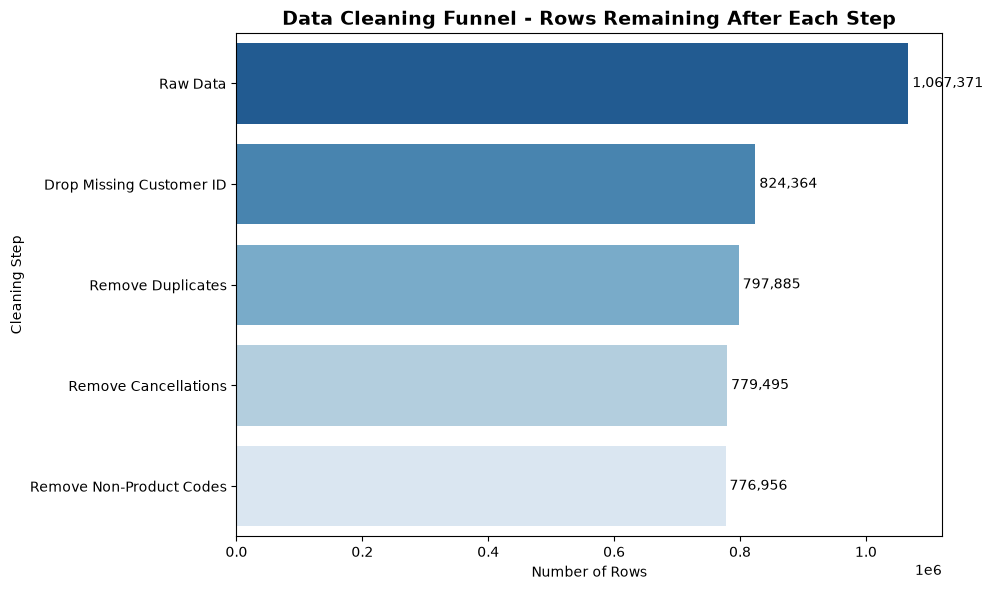

In [11]:
# Plotting Data Funnel
steps, counts = zip(*funnel_steps)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(steps), palette='Blues_r')
plt.title('Data Cleaning Funnel - Rows Remaining After Each Step', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rows')
plt.ylabel('Cleaning Step')

for index, value in enumerate(counts):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()